<a href="https://colab.research.google.com/github/ardiandrazelvan/UTS-citra-digital/blob/main/sample_citra_digital.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving トウカイテイオー！.jpg to トウカイテイオー！.jpg


/tmp/ipykernel_9498/896376803.py:26: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(img))
/tmp/ipykernel_9498/896376803.py:26: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(img))
/tmp/ipykernel_9498/896376803.py:46: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(images[i].ravel(), 256, [0, 256], color='black')
/tmp/ipykernel_9498/896376803.py:51: UserWarning: Glyph 12488 (\N{KATAKANA LETTER TO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9498/896376803.py:51: UserWarning: Glyph 12454 (\N{KATAKANA LETTER U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9498/896376803.py:51: UserWarning: Glyph 12459 (\N{KATAKANA LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9498/896376803.py:51: UserWarning: Glyph 12452 (\N{

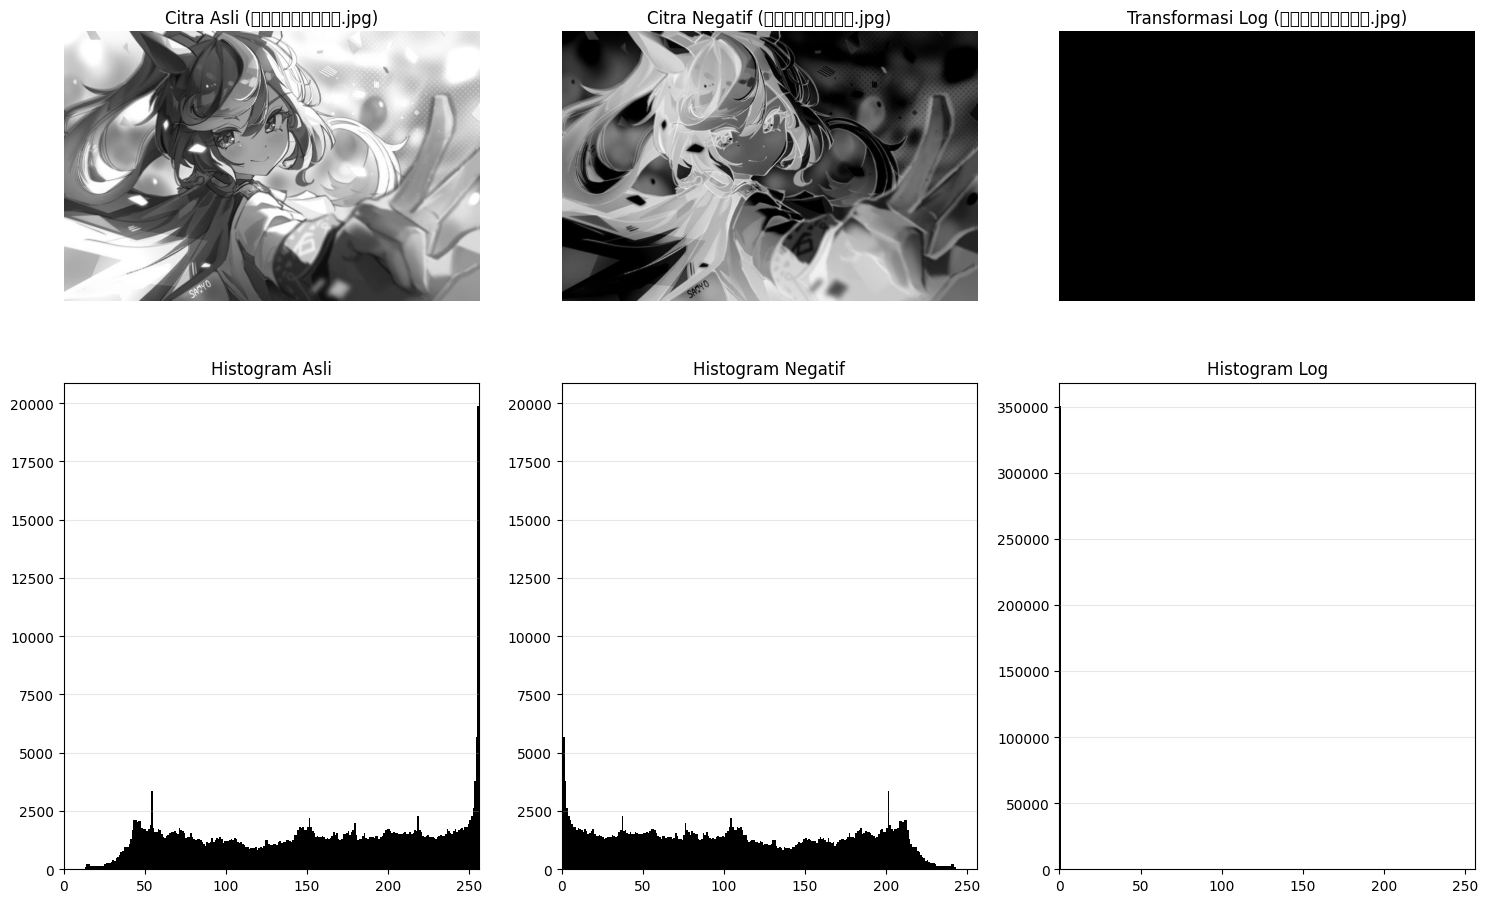

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io
from PIL import Image

# 1. Fungsi untuk mengunggah file
uploaded = files.upload()

for filename in uploaded.keys():
    # Membaca file yang diunggah sebagai array OpenCV
    data = np.frombuffer(uploaded[filename], np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"Gagal membaca file: {filename}")
        continue

    # 2. Transformasi Negatif
    img_negative = 255 - img

    # 3. Transformasi Logaritmik
    # Rumus: G = c * log(1 + F)
    # c = 255 / log(1 + max(F))
    c = 255 / np.log(1 + np.max(img))
    img_log = c * (np.log(1 + img.astype(np.float64)))
    img_log = np.array(img_log, dtype=np.uint8)

    # Menyiapkan visualisasi
    titles = ['Citra Asli', 'Citra Negatif', 'Transformasi Log',
              'Histogram Asli', 'Histogram Negatif', 'Histogram Log']
    images = [img, img_negative, img_log]

    plt.figure(figsize=(15, 10))

    for i in range(3):
        # Tampilkan Gambar
        plt.subplot(2, 3, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f"{titles[i]} ({filename})")
        plt.axis('off')

        # Tampilkan Histogram
        plt.subplot(2, 3, i+4)
        plt.hist(images[i].ravel(), 256, [0, 256], color='black')
        plt.title(titles[i+3])
        plt.xlim([0, 256])
        plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()